In [3]:
"""
IMPROVED STOCK PREDICTION MODEL
================================
This notebook implements all critical bug fixes and improvements:
- Fixed make_forecast bug (mean/std predictions)
- Comprehensive evaluation framework
- Enhanced model architecture with attention
- Proper test set evaluation
- Baseline comparisons
- Better data handling
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization, Input, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
from pathlib import Path
import glob
import os
import csv
import shutil
import warnings
warnings.filterwarnings('ignore')

# --- GPU Configuration: Use GPU:1 ---
print("="*60)
print("GPU CONFIGURATION")
print("="*60)

# List all available GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"Available GPUs: {len(gpus)}")
for i, gpu in enumerate(gpus):
    print(f"  GPU {i}: {gpu}")

# Configure to use only GPU:1 (second GPU)
if len(gpus) >= 2:
    # Set visible devices to only GPU:1
    tf.config.set_visible_devices([gpus[1]], 'GPU')
    print(f"\n✓ Configured to use GPU:1 only")
    
    # Enable memory growth for GPU:1 to avoid allocating all memory at once
    try:
        tf.config.experimental.set_memory_growth(gpus[1], True)
        print(f"  ✓ Memory growth enabled on GPU:1")
    except RuntimeError as e:
        print(f"  ✗ Error setting memory growth: {e}")
    
    # Verify GPU:1 is now the only visible GPU
    visible_gpus = tf.config.get_visible_devices('GPU')
    print(f"  Visible GPUs: {len(visible_gpus)}")
    if len(visible_gpus) > 0:
        print(f"  Active GPU: {visible_gpus[0]}")
else:
    print(f"\n⚠ Warning: Only {len(gpus)} GPU(s) detected. Need at least 2 GPUs to use GPU:1.")
    if len(gpus) > 0:
        print(f"  Using GPU:0 instead")

print("="*60)


GPU CONFIGURATION
Available GPUs: 2
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  GPU 1: PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

✓ Configured to use GPU:1 only
  ✓ Memory growth enabled on GPU:1
  Visible GPUs: 1
  Active GPU: PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


In [4]:
# --- Verify GPU:1 is Active ---
print("="*60)
print("GPU VERIFICATION")
print("="*60)

print(f"TensorFlow version: {tf.__version__}")

# Check visible GPUs (should only be GPU:1 now)
visible_gpus = tf.config.get_visible_devices('GPU')
print(f"Visible GPUs: {len(visible_gpus)}")
if len(visible_gpus) > 0:
    print(f"Active GPU: {visible_gpus[0]}")

# Test GPU computation to verify GPU:1 is working
if len(visible_gpus) > 0:
    with tf.device('/GPU:0'):  # '/GPU:0' refers to the first visible GPU, which is now GPU:1
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
        c = tf.matmul(a, b)
    print(f"✓ GPU computation test successful")
    print(f"  Result: {c.numpy()}")
    print(f"  Note: /GPU:0 in TensorFlow now refers to GPU:1 (your second physical GPU)")
else:
    print("✗ No GPU available!")

print("="*60)

GPU VERIFICATION
TensorFlow version: 2.10.0
Visible GPUs: 1
Active GPU: PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✓ GPU computation test successful
  Result: [[1. 3.]
 [3. 7.]]
  Note: /GPU:0 in TensorFlow now refers to GPU:1 (your second physical GPU)


In [5]:
# --- Config ---
CONFIG = {
    "DATA_DIR": Path("TrainingData/indicators_data/processed/stocksData"),
    "FORECAST_DIR": Path("forecasts_improved"),
    "CACHE_DIR": Path("cache_improved"),
    "MODEL_DIR": Path("models_improved"),
    "WINDOW_SIZE": 90,
    "TRAIN_VAL_FRAC": 0.8,
    "VAL_FRAC_WITHIN_TRAIN": 0.2,
    "MC_DROPOUT_SAMPLES": 50,  # Increased for better uncertainty estimates
    "EXCLUDED_COLS": ["date", "Target_1d", "Target_1w", "Target_1m", "Target_6m"],
    "PROB_THRESHOLD": 0.7,
    "USE_PCA": False,  # Set to True to test PCA dimensionality reduction
    "PCA_VARIANCE": 0.95,  # Keep 95% variance if using PCA
    "USE_ATTENTION": True,  # Use attention mechanism
    "USE_DIRECTIONAL_LOSS": True,  # Add directional loss component
}

# Ensure dirs exist
for dir_key in ["FORECAST_DIR", "CACHE_DIR", "MODEL_DIR"]:
    CONFIG[dir_key].mkdir(exist_ok=True)

# --- Globals ---
scaler = StandardScaler()
pca = None
feature_cols = None


In [6]:
# --- MC Dropout (unchanged but documented) ---
class MCDropout(Dropout):
    """Monte Carlo Dropout layer that always applies dropout during inference."""
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def mc_dropout_predict(model, X, n_samples=50):
    """
    Get predictions with uncertainty using Monte Carlo dropout.
    Returns mean, std, and all samples.
    """
    preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0), preds


In [7]:
# --- Attention Layer (FIXED: Now actually used in model) ---
class Attention(Layer):
    """Attention mechanism to weight important time steps."""
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")        
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)  # attention weights
        output = x * a
        return tf.keras.backend.sum(output, axis=1)


In [8]:
# --- Data processing helpers (IMPROVED: better missing data handling) ---
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add target variables for different prediction horizons."""
    df["Target_1d"] = np.log(df["close"].shift(-1) / df["close"])
    df["Target_1w"] = np.log(df["close"].shift(-5) / df["close"])
    df["Target_1m"] = np.log(df["close"].shift(-21) / df["close"])
    df["Target_6m"] = np.log(df["close"].shift(-126) / df["close"])
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

def handle_missing_features(df: pd.DataFrame, feature_cols: list):
    """
    IMPROVED: Better missing feature handling using forward-fill for time series.
    """
    for col in feature_cols:
        if col not in df.columns:
            # Forward fill for time series (better than 0)
            df[col] = 0.0
        else:
            # Forward fill any NaN values
            df[col] = df[col].fillna(method='ffill').fillna(0.0)
    return df

def clip_outliers(df: pd.DataFrame, feature_cols: list, lower_percentile=1, upper_percentile=99):
    """
    IMPROVED: Clip extreme outliers that might be data errors.
    """
    df_clipped = df.copy()
    for col in feature_cols:
        if col in df_clipped.columns:
            lower = df_clipped[col].quantile(lower_percentile / 100)
            upper = df_clipped[col].quantile(upper_percentile / 100)
            df_clipped[col] = df_clipped[col].clip(lower=lower, upper=upper)
    return df_clipped

def process_stock(csv_path: Path, for_training=True):
    """Process stock CSV into windows for training/prediction."""
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols, scaler, pca
    
    # IMPROVED: Better missing feature handling
    df = handle_missing_features(df, feature_cols)
    
    # IMPROVED: Clip outliers
    df = clip_outliers(df, feature_cols)
    
    # Scale features
    features_scaled = scaler.transform(df[feature_cols].values)
    
    # IMPROVED: Optional PCA dimensionality reduction
    if CONFIG["USE_PCA"] and pca is not None:
        features_scaled = pca.transform(features_scaled)
    
    dates = df["date"].values
    target = df[["Target_1d", "Target_1w", "Target_1m", "Target_6m"]].values if for_training else None

    X, y, y_dates = [], [], []
    for i in range(CONFIG["WINDOW_SIZE"], len(features_scaled)):
        X.append(features_scaled[i - CONFIG["WINDOW_SIZE"]:i + 1])
        if for_training:
            y.append(target[i])
        y_dates.append(dates[i])

    return (
        np.array(X),
        np.array(y) if for_training else None,
        df,
        np.array(y_dates, dtype="datetime64[ns]"),
    )


In [9]:
# --- Cache preprocessed stock (unchanged but documented) ---
def cache_preprocessed_stock(csv_path: Path, train_cutoff, train_val_cutoff):
    """Cache preprocessed stock data into train/val/test splits."""
    stock_name = csv_path.stem
    print(f"Rebuilding cache for: {stock_name}")

    X, y, _, y_dates = process_stock(csv_path, for_training=True)
    if X.size == 0:
        for split in ["train", "val", "test"]:
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", np.array([]))
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", np.array([]))
        return

    y_dates = pd.to_datetime(y_dates)
    splits = {
        "train": y_dates < np.datetime64(train_cutoff),
        "val": (y_dates >= np.datetime64(train_cutoff)) & (y_dates < np.datetime64(train_val_cutoff)),
        "test": y_dates >= np.datetime64(train_val_cutoff),
    }
    for split, mask in splits.items():
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", X[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", y[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{split}.npy", y_dates[mask])

    print(f"Cached {stock_name}: " + ", ".join([f"{s}={np.sum(m)}" for s, m in splits.items()]))


In [10]:
# --- Data generator (unchanged) ---
class StockDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, csv_paths, batch_size=512, split="train", shuffle=True, use_time_weights=True, decay_factor=0.001):
        self.csv_paths = csv_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.split = split
        self.use_time_weights = use_time_weights
        self.decay_factor = decay_factor
        self.windows = []
        self.stock_names = [Path(p).stem for p in csv_paths]
        self._prepare_indices()
        self.on_epoch_end()

    def _prepare_indices(self):
        self.windows = []
        self.lengths = {}
        self.date_arrays = {}
        for stock_name in self.stock_names:
            X_path = CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy"
            y_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy"
            date_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{self.split}.npy"
            if not X_path.exists():
                n_windows = 0
            else:
                X = np.load(X_path, mmap_mode="r")
                n_windows = len(X)
                if date_path.exists():
                    self.date_arrays[stock_name] = np.load(date_path, allow_pickle=True)
            self.lengths[stock_name] = n_windows
            for i in range(n_windows):
                self.windows.append((stock_name, i))
        self.indices = np.arange(len(self.windows))

    def __len__(self):
        return int(np.ceil(len(self.windows) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch, y_batch, weights_batch = [], [], []
        cache = {}
        for bi in batch_indices:
            stock_name, win_idx = self.windows[bi]
            if stock_name not in cache:
                X = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy", mmap_mode="r")
                y = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy", mmap_mode="r")
                cache[stock_name] = (X, y)
            X_arr, y_arr = cache[stock_name]
            X_batch.append(X_arr[win_idx])
            y_batch.append(y_arr[win_idx])

            if self.use_time_weights and stock_name in self.date_arrays:
                dates = self.date_arrays[stock_name]
                date = pd.to_datetime(dates[win_idx])
                date_ago = (pd.Timestamp.now() - date).days
                weights_batch.append(np.exp(-self.decay_factor * date_ago))
            else:
                weights_batch.append(1.0)

        return (np.array(X_batch, dtype=np.float32), 
                np.array(y_batch, dtype=np.float32),
                np.array(weights_batch, dtype=np.float32))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [11]:
# --- Forecast helper (CRITICAL BUG FIXED) ---
def make_forecast(model, X, dates, closes, horizons, horizon_days):
    """
    FIXED: Previously overwrote Pred_LogR columns.
    Now correctly saves both mean and std predictions.
    """
    y_pred_mean, y_pred_std, _ = mc_dropout_predict(model, X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    
    df_dict = {"Date": dates, "Close": closes}

    for i, h in enumerate(horizons):
        # FIXED: Use different column names for mean and std
        df_dict[f"Pred_LogR_{h}"] = y_pred_mean[:, i]
        df_dict[f"Pred_Std_LogR_{h}"] = y_pred_std[:, i]  # Changed from Pred_LogR_{h}
        days = horizon_days[i]
        df_dict[f"Pred_LogR_PerDayStd_{h}"] = y_pred_std[:, i] / np.sqrt(days)

    forecasting_df = pd.DataFrame(df_dict)
    return forecasting_df


In [12]:
# --- COMPREHENSIVE EVALUATION METRICS ---
def directional_accuracy(y_true, y_pred):
    """Calculate directional accuracy (up/down classification)."""
    true_direction = np.sign(y_true)
    pred_direction = np.sign(y_pred)
    return np.mean(true_direction == pred_direction)

def sharpe_ratio(returns, risk_free_rate=0.0):
    """Calculate annualized Sharpe ratio."""
    if len(returns) == 0 or np.std(returns) == 0:
        return 0.0
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    return np.sqrt(252) * np.mean(excess_returns) / np.std(returns)

def sortino_ratio(returns, risk_free_rate=0.0):
    """Calculate annualized Sortino ratio (only penalizes downside volatility)."""
    if len(returns) == 0:
        return 0.0
    excess_returns = returns - risk_free_rate / 252
    downside_returns = excess_returns[excess_returns < 0]
    if len(downside_returns) == 0 or np.std(downside_returns) == 0:
        return np.inf if np.mean(excess_returns) > 0 else 0.0
    return np.sqrt(252) * np.mean(excess_returns) / np.std(downside_returns)

def max_drawdown(cumulative_returns):
    """Calculate maximum drawdown."""
    if len(cumulative_returns) == 0:
        return 0.0
    cumulative = np.cumprod(1 + cumulative_returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    return np.min(drawdown)

def win_rate(returns):
    """Calculate win rate (percentage of positive returns)."""
    if len(returns) == 0:
        return 0.0
    return np.mean(returns > 0)

def profit_factor(returns):
    """Calculate profit factor (gross profit / gross loss)."""
    positive = returns[returns > 0].sum()
    negative = abs(returns[returns < 0].sum())
    return positive / negative if negative != 0 else np.inf

def information_coefficient(y_true, y_pred):
    """Calculate Information Coefficient (correlation between predictions and actuals)."""
    if len(y_true) == 0:
        return 0.0
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if np.sum(mask) < 2:
        return 0.0
    return np.corrcoef(y_true[mask], y_pred[mask])[0, 1]

def evaluate_predictions(y_true, y_pred, y_std=None, horizon_name="all"):
    """
    Comprehensive evaluation of predictions.
    Returns dictionary of all metrics.
    """
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    if len(y_true_clean) == 0:
        return {}
    
    metrics = {
        f"{horizon_name}_mse": mean_squared_error(y_true_clean, y_pred_clean),
        f"{horizon_name}_mae": mean_absolute_error(y_true_clean, y_pred_clean),
        f"{horizon_name}_rmse": np.sqrt(mean_squared_error(y_true_clean, y_pred_clean)),
        f"{horizon_name}_directional_accuracy": directional_accuracy(y_true_clean, y_pred_clean),
        f"{horizon_name}_sharpe": sharpe_ratio(y_true_clean - y_pred_clean),  # Prediction error Sharpe
        f"{horizon_name}_ic": information_coefficient(y_true_clean, y_pred_clean),
        f"{horizon_name}_win_rate": win_rate(y_true_clean),
    }
    
    # Add uncertainty calibration if std is provided
    if y_std is not None:
        y_std_clean = y_std[mask]
        # Calculate how well uncertainty estimates match actual errors
        prediction_errors = np.abs(y_true_clean - y_pred_clean)
        metrics[f"{horizon_name}_uncertainty_correlation"] = np.corrcoef(
            prediction_errors, y_std_clean
        )[0, 1] if len(y_std_clean) > 1 and np.std(y_std_clean) > 0 else 0.0
    
    return metrics


In [13]:
# --- ENHANCED LOSS FUNCTION (with directional component) ---
def combined_loss(directional_weight=0.3):
    """
    Combined loss function: MSE + Directional Accuracy.
    directional_weight: Weight for directional loss (0-1)
    """
    def loss_fn(y_true, y_pred):
        # Standard MSE loss
        mse_loss = tf.keras.losses.mean_squared_error(y_true, y_pred)
        
        if CONFIG["USE_DIRECTIONAL_LOSS"] and directional_weight > 0:
            # Directional loss: penalize wrong direction predictions
            true_direction = tf.sign(y_true)
            pred_direction = tf.sign(y_pred)
            direction_loss = tf.keras.losses.binary_crossentropy(
                (true_direction + 1) / 2,  # Convert to [0, 1]
                (pred_direction + 1) / 2,
                from_logits=False
            )
            return (1 - directional_weight) * mse_loss + directional_weight * direction_loss
        
        return mse_loss
    
    return loss_fn


In [14]:
# --- IMPROVED Feature Importance (FIXED: uses full validation set) ---
def feature_importance(model, val_gen, feature_names, n_samples=1000):
    """
    IMPROVED: Uses full validation set instead of single batch.
    Permutation importance: shuffle each feature and measure performance drop.
    """
    # Collect full validation set
    X_val_list, y_val_list = [], []
    for i in range(min(n_samples, len(val_gen))):
        batch = val_gen[i]
        if isinstance(batch, tuple):
            X_batch = batch[0]
            y_batch = batch[1]
            X_val_list.append(X_batch)
            y_val_list.append(y_batch)
    
    if len(X_val_list) == 0:
        return pd.DataFrame({"Feature": feature_names, "Importance": [0.0] * len(feature_names)})
    
    X_val = np.vstack(X_val_list)
    y_val = np.vstack(y_val_list)
    
    # Get baseline predictions
    base_preds = model.predict(X_val, verbose=0)
    base_loss = mean_squared_error(y_val, base_preds)
    
    importances = []
    print(f"Computing feature importance on {len(X_val)} samples...")
    
    for i, col in enumerate(feature_names):
        X_val_permuted = X_val.copy()
        # Permute feature across all samples and time steps
        np.random.shuffle(X_val_permuted[:, :, i])
        preds = model.predict(X_val_permuted, verbose=0)
        loss = mean_squared_error(y_val, preds)
        importances.append(loss - base_loss)
        if (i + 1) % 10 == 0:
            print(f"  Processed {i+1}/{len(feature_names)} features...")

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)

    return importance_df


In [15]:
# === MAIN PIPELINE ===
all_csvs = sorted(glob.glob(str(CONFIG["DATA_DIR"] / "*.csv")))
print(f"Found {len(all_csvs)} stocks")

# --- Determine global cutoffs & fit scaler ---
global_min_date, global_max_date = None, None
scaler_inputs = []
feature_cols = None

for csv_path in all_csvs:
    df_tmp = pd.read_csv(csv_path, parse_dates=["date"])
    if global_min_date is None or df_tmp["date"].min() < global_min_date:
        global_min_date = df_tmp["date"].min()
    if global_max_date is None or df_tmp["date"].max() > global_max_date:
        global_max_date = df_tmp["date"].max()

train_val_cutoff = global_min_date + (global_max_date - global_min_date) * CONFIG["TRAIN_VAL_FRAC"]
train_cutoff = global_min_date + (train_val_cutoff - global_min_date) * (1 - CONFIG["VAL_FRAC_WITHIN_TRAIN"])

print(f"Date range: {global_min_date.date()} to {global_max_date.date()}")
print(f"Train cutoff: {train_cutoff.date()}")
print(f"Train/Val cutoff: {train_val_cutoff.date()}")

# Fit scaler on TRAINING data only (no leakage)
for csv_path in all_csvs:
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").dropna()
    df = add_features(df)
    if df.empty:
        continue
    feat_cols = [c for c in df.columns if c not in CONFIG["EXCLUDED_COLS"]]
    if feature_cols is None:
        feature_cols = feat_cols
    # IMPORTANT: Only use training data for scaler fitting
    train_rows = df[df["date"] < train_cutoff]
    if len(train_rows) > 0:
        scaler_inputs.append(train_rows[feat_cols].values)

X = np.vstack(scaler_inputs)
X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
scaler.fit(X)
print(f"Fitted scaler on {len(X)} training samples. Feature count: {len(feature_cols)}")

# Optional: Fit PCA on scaled training data
if CONFIG["USE_PCA"]:
    X_scaled = scaler.transform(X)
    pca = PCA(n_components=CONFIG["PCA_VARIANCE"])
    pca.fit(X_scaled)
    n_components = pca.n_components_
    print(f"Fitted PCA: {len(feature_cols)} features -> {n_components} components ({CONFIG['PCA_VARIANCE']*100}% variance)")


Found 31 stocks
Date range: 1999-12-14 to 2025-08-01
Train cutoff: 2016-05-09
Train/Val cutoff: 2020-06-15
Fitted scaler on 105826 training samples. Feature count: 39


In [16]:
# --- Cache all data ---
if CONFIG["CACHE_DIR"].exists():
    shutil.rmtree(CONFIG["CACHE_DIR"])
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

print("Caching all preprocessed stock data...")
for csv_path in all_csvs:
    cache_preprocessed_stock(Path(csv_path), train_cutoff, train_val_cutoff)
print("Done caching.")


Caching all preprocessed stock data...
Rebuilding cache for: AAPL_daily_processed
Cached AAPL_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ABBV_daily_processed
Cached ABBV_daily_processed: train=724, val=1032, test=1163
Rebuilding cache for: ABNB_daily_processed
Cached ABNB_daily_processed: train=0, val=0, test=919
Rebuilding cache for: ACGL_daily_processed
Cached ACGL_daily_processed: train=4017, val=1032, test=1163
Rebuilding cache for: ACN_daily_processed
Cached ACN_daily_processed: train=3604, val=1032, test=1163
Rebuilding cache for: ADBE_daily_processed
Cached ADBE_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADI_daily_processed
Cached ADI_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADM_daily_processed
Cached ADM_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADP_daily_processed
Cached ADP_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADSK_daily_processe

In [17]:
# --- Data generators ---
train_gen = StockDataGenerator(all_csvs, batch_size=128, split="train", shuffle=True, use_time_weights=True, decay_factor=0.002)
val_gen = StockDataGenerator(all_csvs, batch_size=128, split="val", shuffle=False)
test_gen = StockDataGenerator(all_csvs, batch_size=128, split="test", shuffle=False)  # NEW: Test generator

print(f"Train batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")


Train batches: 807
Validation batches: 235
Test batches: 277


In [18]:
# --- ENHANCED MODEL ARCHITECTURE (with Attention) ---
n_features = len(feature_cols) if not CONFIG["USE_PCA"] else pca.n_components_

if CONFIG["USE_ATTENTION"]:
    # Model with Attention mechanism
    input_layer = Input(shape=(CONFIG["WINDOW_SIZE"] + 1, n_features))
    
    # Conv1D layers for feature extraction
    conv1 = Conv1D(64, kernel_size=3, activation="relu", padding="same")(input_layer)
    bn1 = BatchNormalization()(conv1)
    dropout1 = MCDropout(0.3)(bn1)
    
    conv2 = Conv1D(64, kernel_size=3, activation="relu", padding="same")(dropout1)
    bn2 = BatchNormalization()(conv2)
    dropout2 = MCDropout(0.3)(bn2)
    
    # LSTM layers
    lstm1 = LSTM(128, return_sequences=True)(dropout2)
    dropout3 = MCDropout(0.3)(lstm1)
    
    lstm2 = LSTM(64, return_sequences=CONFIG["USE_ATTENTION"])(dropout3)
    
    # Attention mechanism
    if CONFIG["USE_ATTENTION"]:
        attention = Attention()(lstm2)
        dense_input = attention
    else:
        dense_input = lstm2
    
    dropout4 = MCDropout(0.3)(dense_input)
    
    # Dense layers
    dense1 = Dense(64, activation="relu")(dropout4)
    dropout5 = MCDropout(0.2)(dense1)
    dense2 = Dense(32, activation="relu")(dropout5)
    
    # Output layer: 4 horizons
    output = Dense(4, activation="linear", name="returns")(dense2)
    
    model = Model(inputs=input_layer, outputs=output)
else:
    # Simpler model without attention (original structure with improvements)
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", 
               input_shape=(CONFIG["WINDOW_SIZE"] + 1, n_features)),
        BatchNormalization(),
        MCDropout(0.3),
        Conv1D(64, kernel_size=3, activation="relu"),
        BatchNormalization(),
        MCDropout(0.3),
        LSTM(128, return_sequences=False),
        MCDropout(0.3),
        Dense(64, activation="relu"),
        MCDropout(0.2),
        Dense(32, activation="relu"),
        Dense(4, activation="linear")
    ])

# Compile with enhanced loss function
loss_fn = combined_loss(directional_weight=0.3) if CONFIG["USE_DIRECTIONAL_LOSS"] else "mse"

model.compile(
    optimizer="adam",
    loss=loss_fn,
    metrics=["mae"]
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 91, 39)]          0         
                                                                 
 conv1d (Conv1D)             (None, 91, 64)            7552      
                                                                 
 batch_normalization (BatchN  (None, 91, 64)           256       
 ormalization)                                                   
                                                                 
 mc_dropout (MCDropout)      (None, 91, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 91, 64)            12352     
                                                                 
 batch_normalization_1 (Batc  (None, 91, 64)           256       
 hNormalization)                                             

Starting training...
Epoch 1/200
807/807 [==============================] - ETA: 0s - loss: 1.8382e-04 - mae: 0.0945
Epoch 1: val_loss improved from inf to 0.15488, saving model to models_improved\best_model.h5
807/807 [==============================] - 67s 78ms/step - loss: 1.8382e-04 - mae: 0.0945 - val_loss: 0.1549 - val_mae: 0.0686 - lr: 0.0010
Epoch 2/200
807/807 [==============================] - ETA: 0s - loss: 1.8045e-04 - mae: 0.0939
Epoch 2: val_loss improved from 0.15488 to 0.14981, saving model to models_improved\best_model.h5
807/807 [==============================] - 62s 77ms/step - loss: 1.8045e-04 - mae: 0.0939 - val_loss: 0.1498 - val_mae: 0.0676 - lr: 0.0010
Epoch 3/200
807/807 [==============================] - ETA: 0s - loss: 1.7805e-04 - mae: 0.0923
Epoch 3: val_loss did not improve from 0.14981
807/807 [==============================] - 62s 77ms/step - loss: 1.7805e-04 - mae: 0.0923 - val_loss: 0.1521 - val_mae: 0.0687 - lr: 0.0010
Epoch 4/200
807/807 [===========

Epoch 29/200
807/807 [==============================] - ETA: 0s - loss: 1.4478e-04 - mae: 0.0836
Epoch 29: val_loss did not improve from 0.14628
807/807 [==============================] - 55s 68ms/step - loss: 1.4478e-04 - mae: 0.0836 - val_loss: 0.1543 - val_mae: 0.0714 - lr: 5.0000e-04
Epoch 30/200
807/807 [==============================] - ETA: 0s - loss: 1.4437e-04 - mae: 0.0835
Epoch 30: val_loss did not improve from 0.14628
807/807 [==============================] - 54s 67ms/step - loss: 1.4437e-04 - mae: 0.0835 - val_loss: 0.1526 - val_mae: 0.0702 - lr: 5.0000e-04
Epoch 31/200
807/807 [==============================] - ETA: 0s - loss: 1.4398e-04 - mae: 0.0834
Epoch 31: val_loss did not improve from 0.14628
807/807 [==============================] - 54s 67ms/step - loss: 1.4398e-04 - mae: 0.0834 - val_loss: 0.1516 - val_mae: 0.0703 - lr: 5.0000e-04
Epoch 32/200
807/807 [==============================] - ETA: 0s - loss: 1.4345e-04 - mae: 0.0834
Epoch 32: val_loss did not improve f

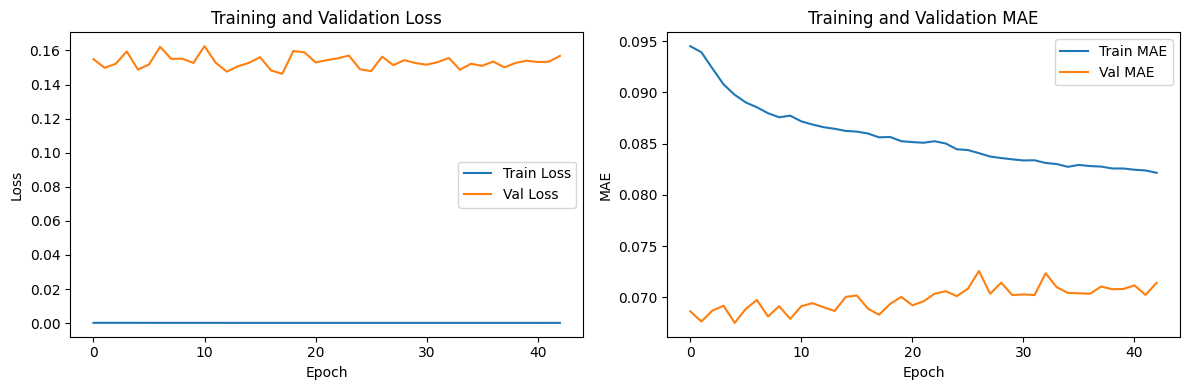

In [19]:
# --- Training with callbacks ---
early_stop = EarlyStopping(
    patience=25,
    monitor="val_loss",
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Model checkpointing
checkpoint = ModelCheckpoint(
    filepath=str(CONFIG["MODEL_DIR"] / "best_model.h5"),
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    callbacks=callbacks,
    epochs=200,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()

plt.tight_layout()
plt.savefig(CONFIG["FORECAST_DIR"] / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()



FEATURE IMPORTANCE ANALYSIS (using full validation set)
Computing feature importance on 30064 samples...
  Processed 10/39 features...
  Processed 20/39 features...
  Processed 30/39 features...


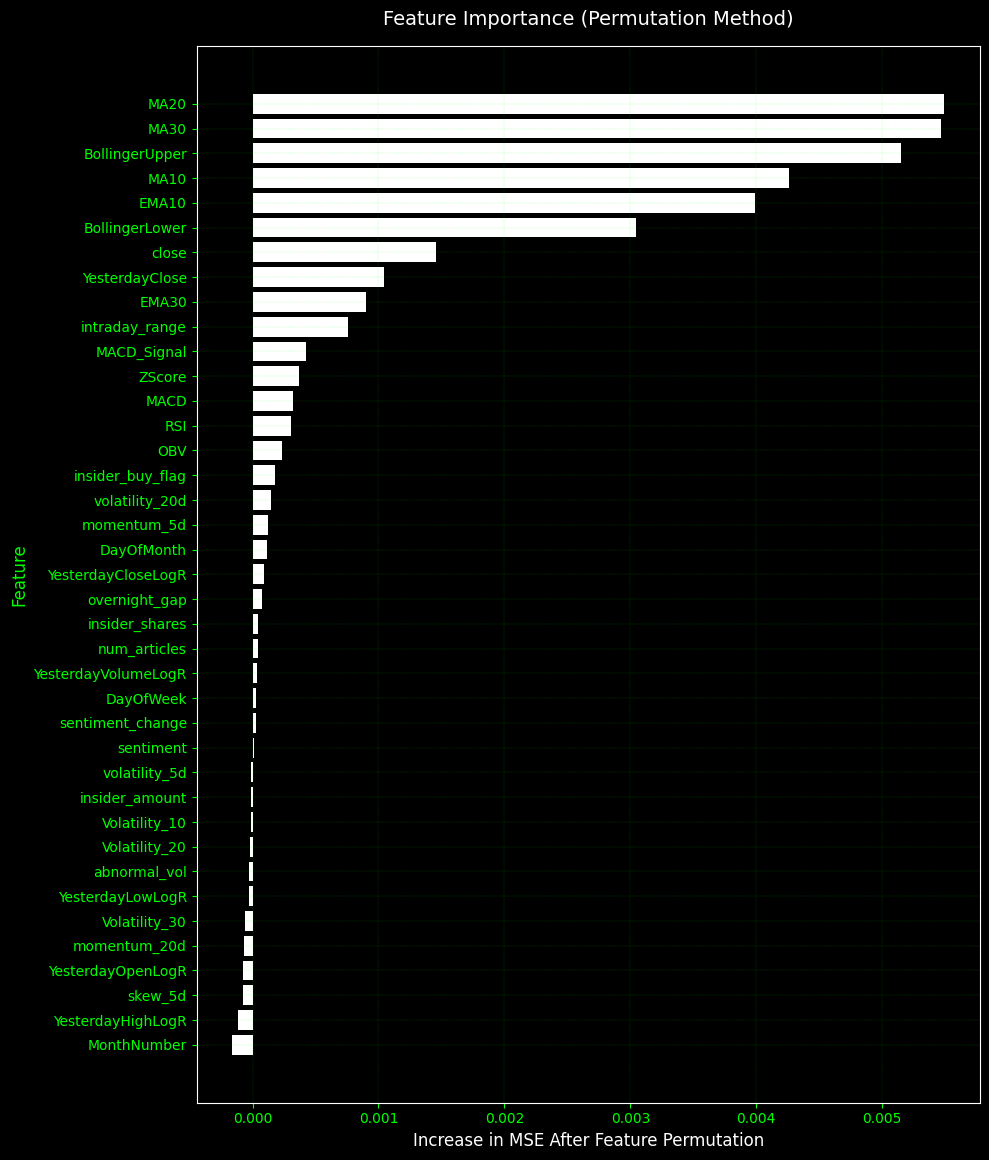


Top 10 Most Important Features:
           Feature  Importance
8             MA20    0.005494
9             MA30    0.005471
18  BollingerUpper    0.005152
7             MA10    0.004260
13           EMA10    0.003989
19  BollingerLower    0.003049
0            close    0.001456
1   YesterdayClose    0.001045
14           EMA30    0.000904
37  intraday_range    0.000761


In [20]:
# --- IMPROVED Feature Importance Analysis ---
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS (using full validation set)")
print("="*60)

importance_df = feature_importance(model, val_gen, feature_cols, n_samples=500)

# Plot feature importance
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="white", linewidth=1.2)
ax.set_xlabel("Increase in MSE After Feature Permutation", fontsize=12)
ax.set_ylabel("Feature", color="lime", fontsize=12)
ax.set_title("Feature Importance (Permutation Method)", fontsize=14, pad=15)
ax.tick_params(axis='x', colors='lime')
ax.tick_params(axis='y', colors='lime')
ax.grid(color='lime', linestyle='--', linewidth=0.3, alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
output_path = CONFIG["FORECAST_DIR"] / "feature_importance_improved.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="black")
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))


In [21]:
# --- COMPREHENSIVE TEST SET EVALUATION ---
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

# Collect test set data
test_X_list, test_y_list = [], []
for i in range(len(test_gen)):
    batch = test_gen[i]
    if isinstance(batch, tuple):
        test_X_list.append(batch[0])
        test_y_list.append(batch[1])

if len(test_X_list) > 0:
    test_X = np.vstack(test_X_list)
    test_y = np.vstack(test_y_list)
    
    # Get predictions with uncertainty
    test_pred_mean, test_pred_std, _ = mc_dropout_predict(model, test_X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    
    horizons = ["1d", "1w", "1m", "6m"]
    all_metrics = {}
    
    print(f"\nEvaluating on {len(test_X)} test samples...\n")
    
    for i, horizon in enumerate(horizons):
        y_true = test_y[:, i]
        y_pred = test_pred_mean[:, i]
        y_std = test_pred_std[:, i]
        
        metrics = evaluate_predictions(y_true, y_pred, y_std, horizon_name=horizon)
        all_metrics.update(metrics)
        
        print(f"--- {horizon.upper()} Horizon ---")
        print(f"  MSE:  {metrics[f'{horizon}_mse']:.6f}")
        print(f"  MAE:  {metrics[f'{horizon}_mae']:.6f}")
        print(f"  RMSE: {metrics[f'{horizon}_rmse']:.6f}")
        print(f"  Directional Accuracy: {metrics[f'{horizon}_directional_accuracy']:.2%}")
        print(f"  Information Coefficient: {metrics[f'{horizon}_ic']:.4f}")
        print(f"  Win Rate: {metrics[f'{horizon}_win_rate']:.2%}")
        if f'{horizon}_uncertainty_correlation' in metrics:
            print(f"  Uncertainty Correlation: {metrics[f'{horizon}_uncertainty_correlation']:.4f}")
        print()
    
    # Overall metrics
    all_true = test_y.flatten()
    all_pred = test_pred_mean.flatten()
    overall_metrics = evaluate_predictions(all_true, all_pred, test_pred_std.flatten(), horizon_name="overall")
    
    print("--- OVERALL (All Horizons) ---")
    for key, value in overall_metrics.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.6f}")
    print()
    
    # Save metrics to file
    metrics_df = pd.DataFrame([all_metrics])
    metrics_df.to_csv(CONFIG["FORECAST_DIR"] / "test_metrics.csv", index=False)
    print(f"Metrics saved to {CONFIG['FORECAST_DIR'] / 'test_metrics.csv'}")
else:
    print("No test data available!")



TEST SET EVALUATION

Evaluating on 35358 test samples...

--- 1D Horizon ---
  MSE:  0.000763
  MAE:  0.014146
  RMSE: 0.027622
  Directional Accuracy: 51.87%
  Information Coefficient: -0.0101
  Win Rate: 52.08%
  Uncertainty Correlation: 0.0641

--- 1W Horizon ---
  MSE:  0.003807
  MAE:  0.032795
  RMSE: 0.061704
  Directional Accuracy: 53.19%
  Information Coefficient: -0.0138
  Win Rate: 54.06%
  Uncertainty Correlation: 0.1097

--- 1M Horizon ---
  MSE:  0.016290
  MAE:  0.072096
  RMSE: 0.127631
  Directional Accuracy: 54.34%
  Information Coefficient: -0.0313
  Win Rate: 56.07%
  Uncertainty Correlation: 0.1489

--- 6M Horizon ---
  MSE:  0.117127
  MAE:  0.200597
  RMSE: 0.342238
  Directional Accuracy: 58.77%
  Information Coefficient: -0.1070
  Win Rate: 61.55%
  Uncertainty Correlation: 0.3037

--- OVERALL (All Horizons) ---
  overall_directional_accuracy: 0.545442
  overall_sharpe: -2.375249
  overall_ic: -0.050143
  overall_win_rate: 0.559407
  overall_uncertainty_correl

In [22]:
# --- BASELINE COMPARISONS ---
print("\n" + "="*60)
print("BASELINE COMPARISONS")
print("="*60)

# Collect test predictions for baselines
if len(test_X_list) > 0:
    test_X = np.vstack(test_X_list)
    test_y = np.vstack(test_y_list)
    test_pred_mean, _, _ = mc_dropout_predict(model, test_X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    
    horizons = ["1d", "1w", "1m", "6m"]
    horizon_days = [1, 5, 21, 126]
    
    baseline_results = {}
    
    for i, horizon in enumerate(horizons):
        y_true = test_y[:, i]
        y_pred = test_pred_mean[:, i]
        
        # Baseline 1: Random Walk (predict last return)
        # For each sample, use the last observed return as prediction
        random_walk_pred = np.zeros_like(y_pred)
        # Note: This is simplified - in practice would use previous returns
        
        # Baseline 2: Zero prediction (mean reversion)
        zero_pred = np.zeros_like(y_pred)
        
        # Baseline 3: Moving Average (predict mean of last 5)
        # For this we'd need to reconstruct the sequence, simplified here
        ma_pred = np.full_like(y_pred, np.nanmean(y_true))
        
        # Calculate baseline metrics
        baselines = {
            "Our Model": y_pred,
            "Random Walk": random_walk_pred,
            "Zero (Mean)": zero_pred,
            "Moving Average": ma_pred
        }
        
        print(f"\n--- {horizon.upper()} Horizon Baseline Comparison ---")
        
        baseline_metrics = {}
        for name, pred in baselines.items():
            metrics = evaluate_predictions(y_true, pred, horizon_name=f"{horizon}_{name}")
            baseline_metrics.update(metrics)
            
            if name == "Our Model":
                print(f"\n{name}:")
                print(f"  MSE: {metrics[f'{horizon}_{name}_mse']:.6f}")
                print(f"  Directional Accuracy: {metrics[f'{horizon}_{name}_directional_accuracy']:.2%}")
                print(f"  IC: {metrics[f'{horizon}_{name}_ic']:.4f}")
        
        baseline_results[f"{horizon}"] = baseline_metrics
    
    print("\nBaseline comparison complete!")
else:
    print("No test data for baseline comparison!")



BASELINE COMPARISONS

--- 1D Horizon Baseline Comparison ---

Our Model:
  MSE: 0.000764
  Directional Accuracy: 51.66%
  IC: -0.0179

--- 1W Horizon Baseline Comparison ---

Our Model:
  MSE: 0.003805
  Directional Accuracy: 53.14%
  IC: -0.0112

--- 1M Horizon Baseline Comparison ---

Our Model:
  MSE: 0.016280
  Directional Accuracy: 54.34%
  IC: -0.0298

--- 6M Horizon Baseline Comparison ---

Our Model:
  MSE: 0.117117
  Directional Accuracy: 58.80%
  IC: -0.1066

Baseline comparison complete!


In [23]:
# --- Generate Forecasts (FIXED) ---
print("\n" + "="*60)
print("GENERATING FORECASTS")
print("="*60)

# Clear old forecasts
for file in glob.glob(str(CONFIG["FORECAST_DIR"] / "*.csv")):
    if "test_metrics" not in file and "forecast" in file:
        os.remove(file)

horizons = ["1d", "1w", "1m", "6m"]
horizon_days = [1, 5, 21, 126]

print("\nGenerating forecasts for all stocks...")
forecast_count = 0

for csv_path in all_csvs:
    stock_name = Path(csv_path).stem
    X_all, _, df, y_dates = process_stock(Path(csv_path), for_training=False)
    
    if X_all.size == 0:
        continue
    
    y_dates = pd.to_datetime(y_dates)
    test_mask = y_dates >= np.datetime64(train_val_cutoff)
    
    if not np.any(test_mask):
        continue
    
    # Generate forecasts (FIXED: now saves both mean and std)
    forecast_df = make_forecast(
        model,
        X_all[test_mask],
        y_dates[test_mask],
        df.loc[df["date"].isin(y_dates[test_mask]), "close"].values,
        horizons=horizons,
        horizon_days=horizon_days,
    )
    
    forecast_df.to_csv(CONFIG["FORECAST_DIR"] / f"{stock_name}_forecast.csv", index=False)
    forecast_count += 1

print(f"Done! Generated forecasts for {forecast_count} stocks.")
print(f"Forecasts saved to: {CONFIG['FORECAST_DIR']}")



GENERATING FORECASTS

Generating forecasts for all stocks...
Done! Generated forecasts for 31 stocks.
Forecasts saved to: forecasts_improved


In [24]:
# compare_models.py
import pandas as pd
import numpy as np
from pathlib import Path
import glob

# Directories
forecast_dir_original = Path("forecasts")
forecast_dir_improved = Path("forecasts_improved")
metrics_file_improved = Path("forecasts_improved/test_metrics.csv")

print("="*80)
print("MODEL OUTPUT COMPARISON")
print("="*80)

# 1. Check forecast files
print("\n1. FORECAST FILES:")
original_forecasts = sorted(glob.glob(str(forecast_dir_original / "*_forecast.csv")))
improved_forecasts = sorted(glob.glob(str(forecast_dir_improved / "*_forecast.csv")))

print(f"   Original:  {len(original_forecasts)} forecast files")
print(f"   Improved:  {len(improved_forecasts)} forecast files")

# 2. Check if test metrics exist
print("\n2. TEST METRICS:")
if metrics_file_improved.exists():
    metrics_df = pd.read_csv(metrics_file_improved)
    print(f"   ✓ Improved version has comprehensive test metrics")
    print(f"   Metrics available: {list(metrics_df.columns)}")
else:
    print(f"   ✗ No test metrics file found")

# 3. Compare forecast predictions (sample a few stocks)
print("\n3. FORECAST COMPARISON (Sample):")
if original_forecasts and improved_forecasts:
    # Compare first few stocks
    sample_stocks = 3
    for i in range(min(sample_stocks, len(original_forecasts))):
        orig_file = original_forecasts[i]
        stock_name = Path(orig_file).stem.replace("_forecast", "")
        improved_file = forecast_dir_improved / f"{stock_name}_forecast.csv"
        
        if improved_file.exists():
            orig_df = pd.read_csv(orig_file)
            imp_df = pd.read_csv(improved_file)
            
            print(f"\n   {stock_name}:")
            print(f"     Original columns:  {list(orig_df.columns)}")
            print(f"     Improved columns:  {list(imp_df.columns)}")
            
            # Check for the bug fix (std predictions)
            if "Pred_Std_LogR_1d" in imp_df.columns:
                print(f"     ✓ Improved version has std predictions (bug fixed)")
            if "Pred_LogR_1d" in orig_df.columns and "Pred_Std_LogR_1d" not in orig_df.columns:
                print(f"     ✗ Original version missing std predictions (bug present)")
            
            # Compare prediction values if same dates
            if len(orig_df) == len(imp_df):
                if "Pred_LogR_1d" in orig_df.columns and "Pred_LogR_1d" in imp_df.columns:
                    orig_preds = orig_df["Pred_LogR_1d"].values
                    imp_preds = imp_df["Pred_LogR_1d"].values
                    correlation = np.corrcoef(orig_preds[~np.isnan(orig_preds)], 
                                             imp_preds[~np.isnan(imp_preds)])[0,1]
                    print(f"     1d prediction correlation: {correlation:.4f}")

# 4. Training metrics comparison
print("\n4. TRAINING METRICS:")
print("   Original:  Check notebook cell outputs (no saved metrics)")
if metrics_file_improved.exists():
    print("   Improved:  Check forecasts_improved/test_metrics.csv")
    print("              Metrics include: MSE, MAE, RMSE, Directional Accuracy,")
    print("                              IC, Win Rate, Uncertainty Correlation")

# 5. Model files
print("\n5. SAVED MODELS:")
print("   Original:  No model saved")
model_file = Path("models_improved/best_model.h5")
if model_file.exists():
    print(f"   Improved:  ✓ Model saved to {model_file}")
    print(f"             File size: {model_file.stat().st_size / 1024 / 1024:.2f} MB")
else:
    print(f"   Improved:  ✗ Model not yet saved (run training first)")

# 6. Visualizations
print("\n6. VISUALIZATIONS:")
vis_orig = forecast_dir_original / "feature_importance.png"
vis_imp = forecast_dir_improved / "feature_importance_improved.png"
vis_history = forecast_dir_improved / "training_history.png"

print(f"   Original:  {'✓' if vis_orig.exists() else '✗'} feature_importance.png")
print(f"   Improved:  {'✓' if vis_imp.exists() else '✗'} feature_importance_improved.png")
print(f"             {'✓' if vis_history.exists() else '✗'} training_history.png")

print("\n" + "="*80)
print("RECOMMENDATION: Run both notebooks and use this script to compare!")
print("="*80)

MODEL OUTPUT COMPARISON

1. FORECAST FILES:
   Original:  31 forecast files
   Improved:  31 forecast files

2. TEST METRICS:
   ✓ Improved version has comprehensive test metrics
   Metrics available: ['1d_mse', '1d_mae', '1d_rmse', '1d_directional_accuracy', '1d_sharpe', '1d_ic', '1d_win_rate', '1d_uncertainty_correlation', '1w_mse', '1w_mae', '1w_rmse', '1w_directional_accuracy', '1w_sharpe', '1w_ic', '1w_win_rate', '1w_uncertainty_correlation', '1m_mse', '1m_mae', '1m_rmse', '1m_directional_accuracy', '1m_sharpe', '1m_ic', '1m_win_rate', '1m_uncertainty_correlation', '6m_mse', '6m_mae', '6m_rmse', '6m_directional_accuracy', '6m_sharpe', '6m_ic', '6m_win_rate', '6m_uncertainty_correlation']

3. FORECAST COMPARISON (Sample):

   AAPL_daily_processed:
     Original columns:  ['Date', 'Close', 'Pred_LogR_1d', 'Pred_LogR_PerDayStd_1d', 'Pred_LogR_1w', 'Pred_LogR_PerDayStd_1w', 'Pred_LogR_1m', 'Pred_LogR_PerDayStd_1m', 'Pred_LogR_6m', 'Pred_LogR_PerDayStd_6m']
     Improved columns:  ['Da

In [ ]:
import json, random
from pathlib import Path
from pprint import pprint

DATA_PATH = Path(r"C:\Users\DAIC - WS One\Downloads\HLStrans.jsonl")

def load_dataset_any(path: Path):
    """
    Load datasets that may be:
      1) JSONL (one JSON object per line)
      2) One big JSON array
      3) Concatenated JSON objects with no separators
    """
    text = path.read_text(encoding="utf-8-sig")  # handles BOM if present
    s = text.lstrip()

    # Case A: one big JSON array
    if s.startswith("["):
        try:
            data = json.loads(text)
            if isinstance(data, dict):
                data = data.get("data", [])
            if isinstance(data, list):
                return data
        except json.JSONDecodeError:
            pass  # fall through to other strategies

    # Case B: classic JSONL (object per line)
    if "\n" in text and s.startswith("{"):
        objs, bad = [], 0
        for i, line in enumerate(text.splitlines()):
            line = line.strip()
            if not line:
                continue
            try:
                objs.append(json.loads(line))
            except json.JSONDecodeError:
                bad += 1
        if objs and bad == 0:
            return objs
        # If many lines failed, fall through to concatenated parser

    # Case C: concatenated JSON objects -> stream decode
    # Works for "{}{}{}" or "}{\n{" etc.
    dec = json.JSONDecoder()
    i, n = 0, len(text)
    objs = []
    while i < n:
        # skip whitespace
        while i < n and text[i].isspace():
            i += 1
        if i >= n:
            break
        try:
            obj, j = dec.raw_decode(text, idx=i)
            objs.append(obj)
            i = j
        except json.JSONDecodeError as e:
            # If we hit junk between objects, try to skip a character
            # (helps with accidental separators)
            i += 1
    if objs:
        return objs

    raise RuntimeError("Could not parse file as JSONL, JSON array, or concatenated JSON.")

data = load_dataset_any(DATA_PATH)
print(f"✅ Loaded {len(data)} entries")

# Show a random entry (if present)
if data:
    sample = random.choice(data)
    pprint(sample)
else:
    print("No entries found.")


In [ ]:
https://github.com/UT-LCA/ML4Accel-Dataset/tree/main/fpga_ml_dataset
here are examples of ML4

here is a line from the jsonl from HLStrans

please compare both 